# Feature Engineering v2 — Dự báo Nguy cơ Trả hàng (Order Return Prediction)

Notebook này xây dựng **tập đặc trưng hoàn chỉnh** cho bài toán dự đoán trả hàng ở **cấp đơn hàng**.

## Cải tiến so với v1 (dựa trên EDA Insights)

| Thay đổi | Chi tiết |
| :--- | :--- |
| **Loại bỏ Multicollinearity** | Bỏ `max_unit_price` ($r=0.998$ với `avg_unit_price`), bỏ `min_unit_price` |
| **Sửa Data Leakage** | Target-encoded features (category/region/payment return rates) chuyển sang **expanding mean leakage-safe** |
| **Sửa Leakage Review** | Customer review features dùng cumulative leakage-safe |
| **Thêm Features phi tuyến** | `is_cod`, `items_per_product`, `discount_ratio`, `size_variety_ratio`, `color_variety_ratio`, `avg_value_per_item`, `customer_return_tendency` |
| **Loại bỏ Features yếu** | Bỏ `device_type` (EDA: tỷ lệ trả hàng ~6.5% đồng đều giữa Desktop/Mobile/Tablet) |

## Nguyên tắc cốt lõi

| Quy tắc | Giải thích |
| :--- | :--- |
| **Đơn vị dự báo** | `order_id` — 1 đơn hàng |
| **Thời điểm dự báo** | Ngay khi khách bấm Checkout |
| **y=1** | Đơn hàng có **ít nhất 1 sản phẩm** bị trả lại |
| **Dữ liệu KHÔNG được phép** | `ship_date`, `delivery_date`, `return_date`, `return_reason` |
| **Đặc trưng lịch sử** | Tính strictly `order_date < current_order_date` |

## 1. Khởi tạo Môi trường & Tải dữ liệu

In [30]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
if os.path.exists('datathon-2026-round-1'):
    DATA_DIR = 'datathon-2026-round-1'
elif os.path.exists('../datathon-2026-round-1'):
    DATA_DIR = '../datathon-2026-round-1'
else:
    raise FileNotFoundError("Không tìm thấy thư mục datathon-2026-round-1!")
print('Sẵn sàng!')

Sẵn sàng!


In [31]:
# Đọc tất cả bảng dữ liệu
df_orders     = pd.read_csv(os.path.join(DATA_DIR, 'orders.csv'), parse_dates=['order_date'])
df_order_items = pd.read_csv(os.path.join(DATA_DIR, 'order_items.csv'), low_memory=False)
df_returns    = pd.read_csv(os.path.join(DATA_DIR, 'returns.csv'), parse_dates=['return_date'])
df_products   = pd.read_csv(os.path.join(DATA_DIR, 'products.csv'))
df_customers  = pd.read_csv(os.path.join(DATA_DIR, 'customers.csv'), parse_dates=['signup_date'])
df_reviews    = pd.read_csv(os.path.join(DATA_DIR, 'reviews.csv'), parse_dates=['review_date'])
df_geography  = pd.read_csv(os.path.join(DATA_DIR, 'geography.csv'))

print('Tất cả bảng dữ liệu đã được tải thành công!')

Tất cả bảng dữ liệu đã được tải thành công!


## 2. Xây dựng Bảng dữ liệu gốc (Base Dataset)

Tạo bảng dữ liệu ở mức **`order_id`** với biến mục tiêu $y$.

In [32]:
# Lọc đơn hàng đủ điều kiện (delivered/returned)
eligible_statuses = ['delivered', 'returned']
df_eligible = df_orders[df_orders['order_status'].isin(eligible_statuses)].copy()

# Gắn nhãn mục tiêu y ở cấp order
returned_orders = df_returns['order_id'].unique()
df_eligible['is_returned'] = df_eligible['order_id'].isin(returned_orders).astype(int)

# Base dataset = df_eligible (1 dòng = 1 order)
df_base = df_eligible.sort_values('order_date').reset_index(drop=True)

print(f'Base dataset: {df_base.shape[0]:,} orders')
print(f'Return rate: {df_base["is_returned"].mean()*100:.2f}%')
print(f'Date range: {df_base["order_date"].min().date()} → {df_base["order_date"].max().date()}')

Base dataset: 552,858 orders
Return rate: 6.52%
Date range: 2012-07-04 → 2022-12-31


## 3. Nhóm 1: Đặc trưng Thành phần Đơn hàng (Order Composition)

Aggregate thông tin từ `order_items` + `products` lên cấp `order_id`.

> **Thay đổi v2:** Loại bỏ `max_unit_price` và `min_unit_price` khỏi feature set (multicollinearity, $r=0.998$). Giữ `price_range` và `avg_unit_price`.

In [33]:
# Ghép thông tin sản phẩm vào order_items
df_items = df_order_items.merge(df_products, on='product_id', how='left')
df_items['line_total'] = df_items['quantity'] * df_items['unit_price'] - df_items['discount_amount']
df_items['has_discount'] = (df_items['discount_amount'] > 0).astype(int)
df_items['has_promo'] = df_items['promo_id'].notna().astype(int)

# Size ordinal
size_map = {'S': 1, 'M': 2, 'L': 3, 'XL': 4}
df_items['size_ordinal'] = df_items['size'].map(size_map)

# Margin
df_items['product_margin'] = (df_items['price'] - df_items['cogs']) / df_items['price'].clip(lower=1)

# Aggregate lên cấp order_id
order_agg = df_items.groupby('order_id').agg(
    # Counts
    n_products=('product_id', 'nunique'),
    n_items=('quantity', 'sum'),
    n_categories=('category', 'nunique'),
    n_segments=('segment', 'nunique'),
    n_sizes=('size', 'nunique'),
    n_colors=('color', 'nunique'),
    # Value
    order_total_value=('line_total', 'sum'),
    avg_unit_price=('unit_price', 'mean'),
    std_unit_price=('unit_price', 'std'),
    # Discount & Promo
    total_discount=('discount_amount', 'sum'),
    avg_discount=('discount_amount', 'mean'),
    has_any_discount=('has_discount', 'max'),
    discount_item_ratio=('has_discount', 'mean'),  # % items có discount
    has_any_promo=('has_promo', 'max'),
    promo_item_ratio=('has_promo', 'mean'),
    # Product attributes
    avg_size_ordinal=('size_ordinal', 'mean'),
    avg_margin=('product_margin', 'mean'),
    max_margin=('product_margin', 'max'),
    min_margin=('product_margin', 'min'),
).reset_index()

# Fill NaN cho std (orders with 1 item)
order_agg['std_unit_price'] = order_agg['std_unit_price'].fillna(0)

# Price range trong đơn (thay thế cho max_unit_price - min_unit_price)
# Tính riêng rồi merge vì đã bỏ max/min_unit_price khỏi order_agg
price_range_df = df_items.groupby('order_id')['unit_price'].agg(
    price_max='max', price_min='min'
).reset_index()
price_range_df['price_range'] = price_range_df['price_max'] - price_range_df['price_min']
order_agg = order_agg.merge(price_range_df[['order_id', 'price_range']], on='order_id', how='left')

# Discount percentage
order_agg['discount_pct'] = order_agg['total_discount'] / (order_agg['order_total_value'] + order_agg['total_discount']).clip(lower=1)

# Merge vào df_base
df_base = df_base.merge(order_agg, on='order_id', how='left')

print(f'Order composition features: {order_agg.shape[1] - 1} features')
print(f'  n_products: mean={df_base["n_products"].mean():.2f}')
print(f'  order_total_value: mean={df_base["order_total_value"].mean():.0f}')
print(f'  [v2] Đã loại bỏ max_unit_price, min_unit_price (multicollinearity)')

Order composition features: 21 features
  n_products: mean=1.10
  order_total_value: mean=24209
  [v2] Đã loại bỏ max_unit_price, min_unit_price (multicollinearity)


In [34]:
# Dominant category (category chiếm đa số trong đơn)
dominant_cat = df_items.groupby('order_id')['category'].agg(
    lambda x: x.mode().iloc[0] if len(x) > 0 else 'unknown'
).reset_index()
dominant_cat.columns = ['order_id', 'dominant_category']
df_base = df_base.merge(dominant_cat, on='order_id', how='left')

# Dominant segment
dominant_seg = df_items.groupby('order_id')['segment'].agg(
    lambda x: x.mode().iloc[0] if len(x) > 0 else 'unknown'
).reset_index()
dominant_seg.columns = ['order_id', 'dominant_segment']
df_base = df_base.merge(dominant_seg, on='order_id', how='left')

print(f'Dominant category distribution:')
print(df_base['dominant_category'].value_counts().to_string())

Dominant category distribution:
dominant_category
Streetwear    330145
Outdoor       170995
GenZ           31675
Casual         20043


In [35]:
# ===== Historical return rate cho các sản phẩm trong đơn =====
# Tính tỷ lệ return lịch sử của từng product_id, rồi avg lên cấp order
# QUAN TRỌNG: chỉ dùng dữ liệu TRƯỚC thời điểm đơn hiện tại

# Tạo bảng: order_id -> order_date
order_dates = df_base[['order_id', 'order_date']].copy()

# Tạo bảng return history cho mỗi product
# Ghép order_items với order info
items_with_date = df_order_items.merge(order_dates, on='order_id', how='inner')
items_with_date = items_with_date.merge(
    df_returns[['order_id', 'product_id']].drop_duplicates().assign(was_returned=1),
    on=['order_id', 'product_id'], how='left'
)
items_with_date['was_returned'] = items_with_date['was_returned'].fillna(0).astype(int)
items_with_date = items_with_date.sort_values('order_date')

# Cumulative return rate per product (leakage-safe)
items_with_date['prod_cum_returns'] = items_with_date.groupby('product_id')['was_returned'].cumsum()
items_with_date['prod_cum_returns'] = items_with_date.groupby('product_id')['prod_cum_returns'].shift(1).fillna(0)
items_with_date['prod_cum_total'] = items_with_date.groupby('product_id').cumcount()
items_with_date['prod_hist_return_rate'] = items_with_date['prod_cum_returns'] / items_with_date['prod_cum_total'].clip(lower=1)

# Aggregate product historical return rates lên cấp order
order_prod_hist = items_with_date.groupby('order_id').agg(
    avg_prod_hist_return_rate=('prod_hist_return_rate', 'mean'),
    max_prod_hist_return_rate=('prod_hist_return_rate', 'max'),
    sum_prod_hist_returns=('prod_cum_returns', 'sum'),
).reset_index()

df_base = df_base.merge(order_prod_hist, on='order_id', how='left')
for col in ['avg_prod_hist_return_rate', 'max_prod_hist_return_rate', 'sum_prod_hist_returns']:
    df_base[col] = df_base[col].fillna(0)

print('Product historical return features (Leakage-safe):')
print(f'  avg_prod_hist_return_rate: mean={df_base["avg_prod_hist_return_rate"].mean():.4f}')
print(f'  max_prod_hist_return_rate: mean={df_base["max_prod_hist_return_rate"].mean():.4f}')

del items_with_date
gc.collect()

Product historical return features (Leakage-safe):
  avg_prod_hist_return_rate: mean=0.0648
  max_prod_hist_return_rate: mean=0.0654


0

## 4. Nhóm 2: Đặc trưng Khách hàng (Customer Features)

> ⚠️ **Data Leakage Prevention:** Mỗi đặc trưng lịch sử phải dùng `cumsum().shift(1)`.

In [36]:
# Customer Demographics (Static)
df_base = df_base.merge(
    df_customers[['customer_id', 'signup_date', 'gender', 'age_group', 'acquisition_channel']],
    on='customer_id', how='left'
)

# Customer tenure tại thời điểm đặt hàng
df_base['customer_tenure_days'] = (df_base['order_date'] - df_base['signup_date']).dt.days
df_base['customer_tenure_days'] = df_base['customer_tenure_days'].clip(lower=0)

print('Customer demographics merged!')
print(f'  Gender: {df_base["gender"].value_counts().to_dict()}')

Customer demographics merged!
  Gender: {'Female': 270999, 'Male': 260573, 'Non-binary': 21286}


In [37]:
# Customer order number (thứ tự đơn hàng)
df_base = df_base.sort_values(['customer_id', 'order_date']).reset_index(drop=True)
df_base['customer_order_number'] = df_base.groupby('customer_id').cumcount() + 1
df_base['is_first_order'] = (df_base['customer_order_number'] == 1).astype(int)

print(f'Customer order number: min={df_base["customer_order_number"].min()}, '
      f'max={df_base["customer_order_number"].max()}, '
      f'median={df_base["customer_order_number"].median()}')
print(f'First orders: {df_base["is_first_order"].sum():,} ({df_base["is_first_order"].mean()*100:.1f}%)')

Customer order number: min=1, max=97, median=5.0
First orders: 86,691 (15.7%)


In [38]:
# Customer historical return rate & count (Leakage-safe)
df_base = df_base.sort_values(['customer_id', 'order_date']).reset_index(drop=True)

# Cumulative returns per customer (shift 1 to exclude current)
df_base['cust_cum_returns'] = df_base.groupby('customer_id')['is_returned'].cumsum()
df_base['cust_cum_returns'] = df_base.groupby('customer_id')['cust_cum_returns'].shift(1).fillna(0)
df_base['cust_cum_orders'] = df_base.groupby('customer_id').cumcount()  # = order_number - 1

df_base['customer_return_rate'] = df_base['cust_cum_returns'] / df_base['cust_cum_orders'].clip(lower=1)
df_base['customer_return_count'] = df_base['cust_cum_returns']
df_base['customer_total_orders_before'] = df_base['cust_cum_orders']

# Clean up
df_base.drop(columns=['cust_cum_returns', 'cust_cum_orders'], inplace=True)

print('Customer historical return features (Leakage-safe):')
print(f'  customer_return_rate: mean={df_base["customer_return_rate"].mean():.4f}')
print(f'  customer_return_count: mean={df_base["customer_return_count"].mean():.2f}')

Customer historical return features (Leakage-safe):
  customer_return_rate: mean=0.0549
  customer_return_count: mean=0.46


In [39]:
# Customer recency — Số ngày kể từ đơn hàng gần nhất
df_base = df_base.sort_values(['customer_id', 'order_date'])
df_base['prev_order_date'] = df_base.groupby('customer_id')['order_date'].shift(1)
df_base['customer_recency_days'] = (df_base['order_date'] - df_base['prev_order_date']).dt.days
df_base['customer_recency_days'] = df_base['customer_recency_days'].fillna(-1)  # First order = -1
df_base.drop(columns=['prev_order_date'], inplace=True)

# Customer average order value (historical)
df_base = df_base.sort_values(['customer_id', 'order_date'])
df_base['cust_cum_spending'] = df_base.groupby('customer_id')['order_total_value'].cumsum()
df_base['cust_cum_spending'] = df_base.groupby('customer_id')['cust_cum_spending'].shift(1).fillna(0)
df_base['cust_cum_cnt'] = df_base.groupby('customer_id').cumcount()
df_base['customer_avg_order_value'] = df_base['cust_cum_spending'] / df_base['cust_cum_cnt'].clip(lower=1)
df_base['customer_avg_order_value'] = df_base['customer_avg_order_value'].fillna(0)
df_base.drop(columns=['cust_cum_spending', 'cust_cum_cnt'], inplace=True)

print(f'customer_recency_days: mean={df_base[df_base["customer_recency_days"] >= 0]["customer_recency_days"].mean():.1f} days')
print(f'customer_avg_order_value: mean={df_base["customer_avg_order_value"].mean():.2f}')

customer_recency_days: mean=312.7 days
customer_avg_order_value: mean=19226.16


## 5. Nhóm 3: Đặc trưng Kênh đặt hàng (Channel Features)

> **Thay đổi v2:** Loại bỏ `device_type` (EDA: tỷ lệ trả hàng đồng đều ~6.5% giữa Desktop/Mobile/Tablet). Thêm `is_cod` binary feature.

In [40]:
# Các cột channel từ bảng orders (GIỮ payment_method, order_source; BỎ device_type)
# Thêm Region
df_base = df_base.merge(df_geography[['zip', 'region']], on='zip', how='left')

# [v2] Feature mới: is_cod — EDA cho thấy COD có return rate 11.33% vs prepaid ~5.7%
df_base['is_cod'] = (df_base['payment_method'] == 'cod').astype(int)

print('Channel features available:')
print(f'  payment_method: {df_base["payment_method"].nunique()} values')
print(f'  order_source: {df_base["order_source"].nunique()} values')
print(f'  region: {df_base["region"].nunique()} values')
print(f'  [v2] is_cod: {df_base["is_cod"].mean()*100:.1f}% orders are COD')
print(f'  [v2] Đã loại bỏ device_type (noise feature)')

Channel features available:
  payment_method: 5 values
  order_source: 6 values
  region: 3 values
  [v2] is_cod: 13.7% orders are COD
  [v2] Đã loại bỏ device_type (noise feature)


## 6. Nhóm 4: Đặc trưng Thời gian (Temporal Features)

In [41]:
# Calendar features
df_base['order_month'] = df_base['order_date'].dt.month
df_base['order_day_of_week'] = df_base['order_date'].dt.dayofweek
df_base['order_day_of_year'] = df_base['order_date'].dt.dayofyear
df_base['is_weekend'] = df_base['order_day_of_week'].isin([5, 6]).astype(int)
df_base['order_quarter'] = df_base['order_date'].dt.quarter
df_base['order_year'] = df_base['order_date'].dt.year

# Cyclical encoding
df_base['month_sin'] = np.sin(2 * np.pi * df_base['order_month'] / 12)
df_base['month_cos'] = np.cos(2 * np.pi * df_base['order_month'] / 12)
df_base['dow_sin'] = np.sin(2 * np.pi * df_base['order_day_of_week'] / 7)
df_base['dow_cos'] = np.cos(2 * np.pi * df_base['order_day_of_week'] / 7)

print('Temporal features created!')

Temporal features created!


## 7. Nhóm 5: Đặc trưng Tương tác (Interaction Features) — FIXED Leakage

> **Thay đổi v2:** 
> - Customer reviews: dùng **cumulative leakage-safe** thay vì global average
> - Target-encoded return rates: dùng **expanding mean leakage-safe** thay vì global mean

In [42]:
# ===== [v2 FIXED] Customer average rating (Leakage-safe) =====
# Chỉ dùng reviews TRƯỚC thời điểm đơn hiện tại

reviews_with_date = df_reviews.merge(
    df_eligible[['order_id', 'order_date', 'customer_id']],
    on=['order_id', 'customer_id'], how='inner'
)
reviews_with_date = reviews_with_date.sort_values(['customer_id', 'order_date'])

# Cumulative rating per customer (leakage-safe)
reviews_with_date['cum_rating_sum'] = reviews_with_date.groupby('customer_id')['rating'].cumsum()
reviews_with_date['cum_rating_sum'] = reviews_with_date.groupby('customer_id')['cum_rating_sum'].shift(1).fillna(0)
reviews_with_date['cum_review_cnt'] = reviews_with_date.groupby('customer_id').cumcount()
reviews_with_date['hist_avg_rating'] = reviews_with_date['cum_rating_sum'] / reviews_with_date['cum_review_cnt'].clip(lower=1)

# Aggregate lên cấp order (mỗi order chỉ có 1 review tối đa)
cust_review_hist = reviews_with_date.groupby(['order_id', 'customer_id']).agg(
    customer_avg_rating=('hist_avg_rating', 'first'),
    customer_review_count=('cum_review_cnt', 'first'),
).reset_index()

df_base = df_base.merge(cust_review_hist, on=['order_id', 'customer_id'], how='left')
df_base['customer_avg_rating'] = df_base['customer_avg_rating'].fillna(0)
df_base['customer_review_count'] = df_base['customer_review_count'].fillna(0)
df_base['has_reviewed'] = (df_base['customer_review_count'] > 0).astype(int)

print('[v2 FIXED] Customer review features (Leakage-safe):')
print(f'  customer_avg_rating: mean={df_base["customer_avg_rating"].mean():.2f}')
print(f'  Customers with past reviews: {df_base["has_reviewed"].mean()*100:.1f}%')

[v2 FIXED] Customer review features (Leakage-safe):
  customer_avg_rating: mean=0.45
  Customers with past reviews: 11.3%


In [43]:
# ===== [v2 FIXED] Target-encoded return rates (Leakage-safe expanding mean) =====
# Thay vì dùng global mean (LEAKAGE!), dùng cumulative mean chỉ từ dữ liệu TRƯỚC đó

df_base = df_base.sort_values('order_date').reset_index(drop=True)

# --- Category historical return rate ---
df_base['cat_cum_returns'] = df_base.groupby('dominant_category')['is_returned'].cumsum()
df_base['cat_cum_returns'] = df_base.groupby('dominant_category')['cat_cum_returns'].shift(1).fillna(0)
df_base['cat_cum_total'] = df_base.groupby('dominant_category').cumcount()
df_base['category_hist_return_rate'] = df_base['cat_cum_returns'] / df_base['cat_cum_total'].clip(lower=1)
df_base.drop(columns=['cat_cum_returns', 'cat_cum_total'], inplace=True)

# --- Region historical return rate ---
df_base['reg_cum_returns'] = df_base.groupby('region')['is_returned'].cumsum()
df_base['reg_cum_returns'] = df_base.groupby('region')['reg_cum_returns'].shift(1).fillna(0)
df_base['reg_cum_total'] = df_base.groupby('region').cumcount()
df_base['region_hist_return_rate'] = df_base['reg_cum_returns'] / df_base['reg_cum_total'].clip(lower=1)
df_base.drop(columns=['reg_cum_returns', 'reg_cum_total'], inplace=True)

# --- Payment method historical return rate ---
df_base['pay_cum_returns'] = df_base.groupby('payment_method')['is_returned'].cumsum()
df_base['pay_cum_returns'] = df_base.groupby('payment_method')['pay_cum_returns'].shift(1).fillna(0)
df_base['pay_cum_total'] = df_base.groupby('payment_method').cumcount()
df_base['payment_hist_return_rate'] = df_base['pay_cum_returns'] / df_base['pay_cum_total'].clip(lower=1)
df_base.drop(columns=['pay_cum_returns', 'pay_cum_total'], inplace=True)

print('[v2 FIXED] Target-encoded features (Leakage-safe expanding mean):')
print(f'  category_hist_return_rate: mean={df_base["category_hist_return_rate"].mean():.4f}')
print(f'  region_hist_return_rate: mean={df_base["region_hist_return_rate"].mean():.4f}')
print(f'  payment_hist_return_rate: mean={df_base["payment_hist_return_rate"].mean():.4f}')

[v2 FIXED] Target-encoded features (Leakage-safe expanding mean):
  category_hist_return_rate: mean=0.0653
  region_hist_return_rate: mean=0.0654
  payment_hist_return_rate: mean=0.0654


## 8. [v2 MỚI] Đặc trưng Tương tác Phi tuyến

Dựa trên gợi ý EDA: thay vì dùng biến thô đơn lẻ, tạo các biến tỷ lệ/tương tác phi tuyến.

In [44]:
# ===== [v2 MỚI] Nonlinear Interaction Features =====

# 1. items_per_product: hành vi mua gom cùng sản phẩm (EDA gợi ý)
df_base['items_per_product'] = df_base['n_items'] / df_base['n_products'].clip(lower=1)

# 2. discount_ratio: tỷ lệ giảm giá thực tế (EDA gợi ý)
df_base['discount_ratio'] = df_base['total_discount'] / (df_base['order_total_value'] + df_base['total_discount']).clip(lower=1)

# 3. size_variety_ratio: proxy cho "mua thử nhiều size" (EDA gợi ý)
df_base['size_variety_ratio'] = df_base['n_sizes'] / df_base['n_products'].clip(lower=1)

# 4. color_variety_ratio: đa dạng màu sắc trong đơn
df_base['color_variety_ratio'] = df_base['n_colors'] / df_base['n_products'].clip(lower=1)

# 5. avg_value_per_item: giá trị TB mỗi item
df_base['avg_value_per_item'] = df_base['order_total_value'] / df_base['n_items'].clip(lower=1)

# 6. customer_return_tendency: tương tác giữa tỷ lệ return lịch sử và kinh nghiệm
df_base['customer_return_tendency'] = df_base['customer_return_rate'] * df_base['customer_order_number']

print('[v2 MỚI] Nonlinear interaction features created!')
print(f'  items_per_product: mean={df_base["items_per_product"].mean():.2f}')
print(f'  discount_ratio: mean={df_base["discount_ratio"].mean():.4f}')
print(f'  size_variety_ratio: mean={df_base["size_variety_ratio"].mean():.2f}')
print(f'  color_variety_ratio: mean={df_base["color_variety_ratio"].mean():.2f}')
print(f'  avg_value_per_item: mean={df_base["avg_value_per_item"].mean():.0f}')
print(f'  customer_return_tendency: mean={df_base["customer_return_tendency"].mean():.2f}')

[v2 MỚI] Nonlinear interaction features created!
  items_per_product: mean=4.49
  discount_ratio: mean=0.0541
  size_variety_ratio: mean=1.00
  color_variety_ratio: mean=1.00
  avg_value_per_item: mean=5148
  customer_return_tendency: mean=0.52


## 9. Tổng kết Đặc trưng & Kiểm tra

In [45]:
# Danh sách features
ID_COLS = ['order_id', 'order_date', 'customer_id']
TARGET_COL = 'is_returned'

# [v2] Bỏ device_type
CATEGORICAL_FEATURES = [
    'payment_method', 'order_source',
    'gender', 'age_group', 'acquisition_channel', 'region',
    'dominant_category', 'dominant_segment'
]

# [v2] Bỏ max_unit_price, min_unit_price; thêm features mới; sửa tên leakage-safe
NUMERIC_FEATURES = [
    # Order composition (v2: bỏ max_unit_price, min_unit_price)
    'n_products', 'n_items', 'n_categories', 'n_segments', 'n_sizes', 'n_colors',
    'order_total_value', 'avg_unit_price', 'std_unit_price',
    'total_discount', 'avg_discount', 'has_any_discount', 'discount_item_ratio', 'discount_pct',
    'has_any_promo', 'promo_item_ratio',
    'avg_size_ordinal', 'avg_margin', 'max_margin', 'min_margin', 'price_range',
    'avg_prod_hist_return_rate', 'max_prod_hist_return_rate', 'sum_prod_hist_returns',
    # v2 MỚI: Nonlinear interaction features
    'is_cod', 'items_per_product', 'discount_ratio',
    'size_variety_ratio', 'color_variety_ratio',
    'avg_value_per_item', 'customer_return_tendency',
    # Customer features
    'customer_tenure_days', 'customer_order_number', 'is_first_order',
    'customer_return_rate', 'customer_return_count', 'customer_total_orders_before',
    'customer_recency_days', 'customer_avg_order_value',
    # Temporal features
    'order_month', 'order_day_of_week', 'is_weekend', 'order_quarter', 'order_year',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    # Interaction features (v2 FIXED: leakage-safe)
    'customer_avg_rating', 'customer_review_count', 'has_reviewed',
    'category_hist_return_rate', 'region_hist_return_rate', 'payment_hist_return_rate',
]

print(f'=== TỔNG KẾT ĐẶC TRƯNG (v2) ===')
print(f'  Categorical features: {len(CATEGORICAL_FEATURES)}')
print(f'  Numeric features: {len(NUMERIC_FEATURES)}')
print(f'  Total features: {len(CATEGORICAL_FEATURES) + len(NUMERIC_FEATURES)}')
print(f'\nDataset shape: {df_base.shape}')

=== TỔNG KẾT ĐẶC TRƯNG (v2) ===
  Categorical features: 8
  Numeric features: 54
  Total features: 62

Dataset shape: (552858, 71)


In [46]:
# Kiểm tra missing values
missing_info = df_base[NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET_COL]].isnull().sum()
missing_info = missing_info[missing_info > 0].sort_values(ascending=False)

if len(missing_info) > 0:
    print('=== CÁC CỘT CÓ MISSING VALUES ===')
    for col, count in missing_info.items():
        print(f'  {col}: {count:,} ({count/len(df_base)*100:.2f}%)')
else:
    print('Không có missing values trong các cột features! ✅')

Không có missing values trong các cột features! ✅


In [47]:
# [v2] Verify multicollinearity đã giải quyết
print('=== KIỂM TRA MULTICOLLINEARITY (v2) ===')
price_cols = ['avg_unit_price', 'std_unit_price', 'price_range', 'avg_value_per_item']
corr_price = df_base[price_cols].corr()
print('Tương quan giữa các biến giá (sau khi loại bỏ max/min_unit_price):')
print(corr_price.round(3).to_string())
print('\n✅ Đã loại bỏ max_unit_price (r=0.998 với avg_unit_price) và min_unit_price')

=== KIỂM TRA MULTICOLLINEARITY (v2) ===
Tương quan giữa các biến giá (sau khi loại bỏ max/min_unit_price):
                    avg_unit_price  std_unit_price  price_range  avg_value_per_item
avg_unit_price               1.000           0.008        0.007               0.993
std_unit_price               0.008           1.000        0.998               0.009
price_range                  0.007           0.998        1.000               0.008
avg_value_per_item           0.993           0.009        0.008               1.000

✅ Đã loại bỏ max_unit_price (r=0.998 với avg_unit_price) và min_unit_price


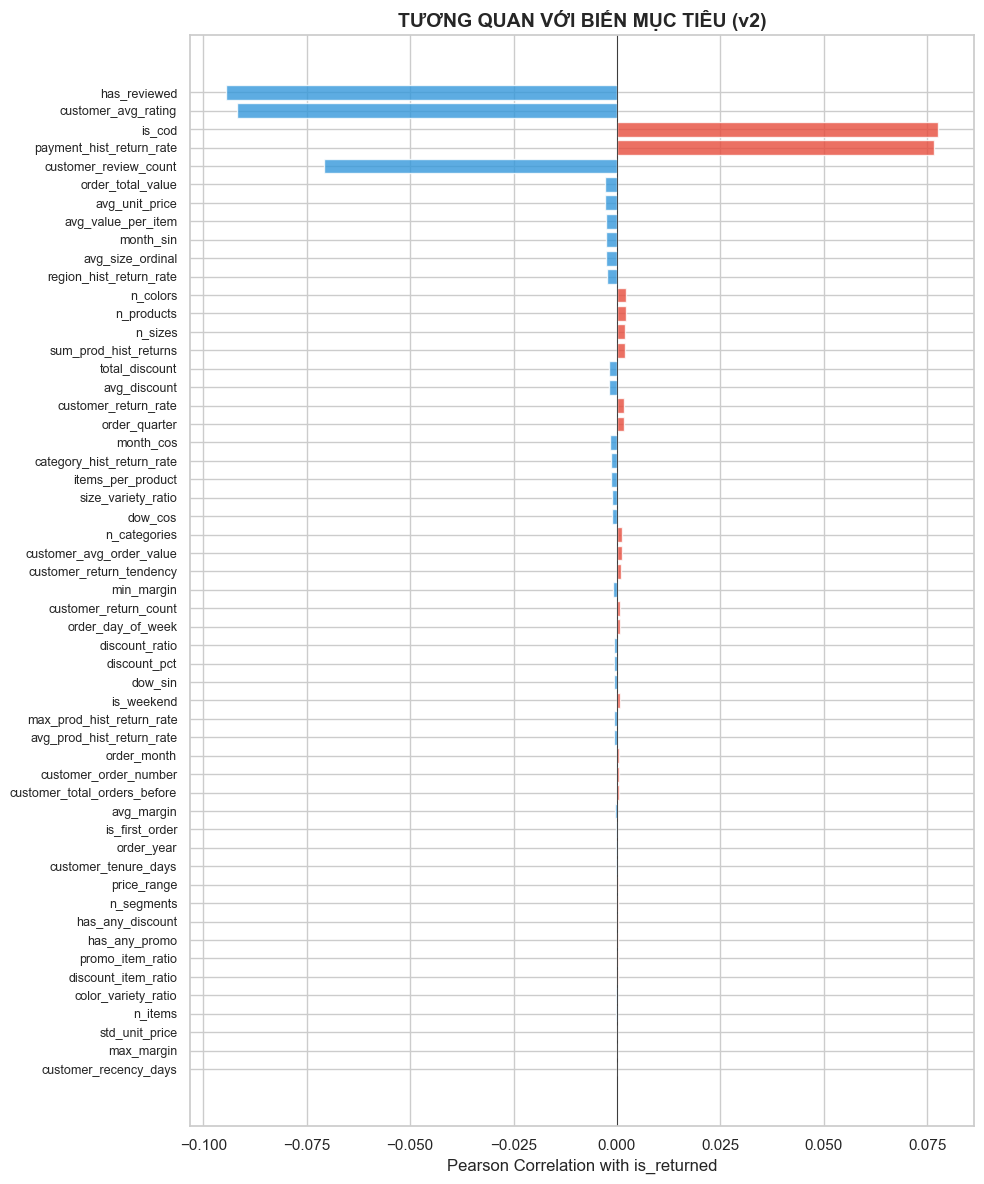


Tương quan với biến mục tiêu (is_returned):
  has_reviewed                            : -0.0945
  customer_avg_rating                     : -0.0918
  is_cod                                  : +0.0777
  payment_hist_return_rate                : +0.0766
  customer_review_count                   : -0.0708
  order_total_value                       : -0.0029
  avg_unit_price                          : -0.0028
  avg_value_per_item                      : -0.0027
  month_sin                               : -0.0025
  avg_size_ordinal                        : -0.0025
  region_hist_return_rate                 : -0.0023
  n_colors                                : +0.0023
  n_products                              : +0.0022
  n_sizes                                 : +0.0021
  sum_prod_hist_returns                   : +0.0019
  total_discount                          : -0.0019
  avg_discount                            : -0.0019
  customer_return_rate                    : +0.0018
  order_quarter    

In [48]:
# [v2] Correlation heatmap với target
corr_target = df_base[NUMERIC_FEATURES + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL)
corr_target = corr_target.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_target.values]
ax.barh(range(len(corr_target)), corr_target.values, color=colors, alpha=0.8)
ax.set_yticks(range(len(corr_target)))
ax.set_yticklabels(corr_target.index, fontsize=9)
ax.set_xlabel('Pearson Correlation with is_returned')
ax.set_title('TƯƠNG QUAN VỚI BIẾN MỤC TIÊU (v2)', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\nTương quan với biến mục tiêu (is_returned):')
for feat, val in corr_target.items():
    print(f'  {feat:40s}: {val:+.4f}')

## 10. Train/Test Split (Temporal)

In [49]:
# Temporal split: train trước 2022-07-01, test từ 2022-07-01
CUTOFF_DATE = '2022-07-01'
df_base = df_base.sort_values('order_date').reset_index(drop=True)

df_train = df_base[df_base['order_date'] < CUTOFF_DATE].copy()
df_test = df_base[df_base['order_date'] >= CUTOFF_DATE].copy()

print(f'Temporal split at {CUTOFF_DATE}')
print(f'  TRAIN: {df_train.shape[0]:,} orders ({df_train["order_date"].min().date()} → {df_train["order_date"].max().date()})')
print(f'    Return rate: {df_train["is_returned"].mean()*100:.2f}%')
print(f'  TEST:  {df_test.shape[0]:,} orders ({df_test["order_date"].min().date()} → {df_test["order_date"].max().date()})')
print(f'    Return rate: {df_test["is_returned"].mean()*100:.2f}%')

Temporal split at 2022-07-01
  TRAIN: 540,277 orders (2012-07-04 → 2022-06-30)
    Return rate: 6.52%
  TEST:  12,581 orders (2022-07-01 → 2022-12-31)
    Return rate: 6.61%


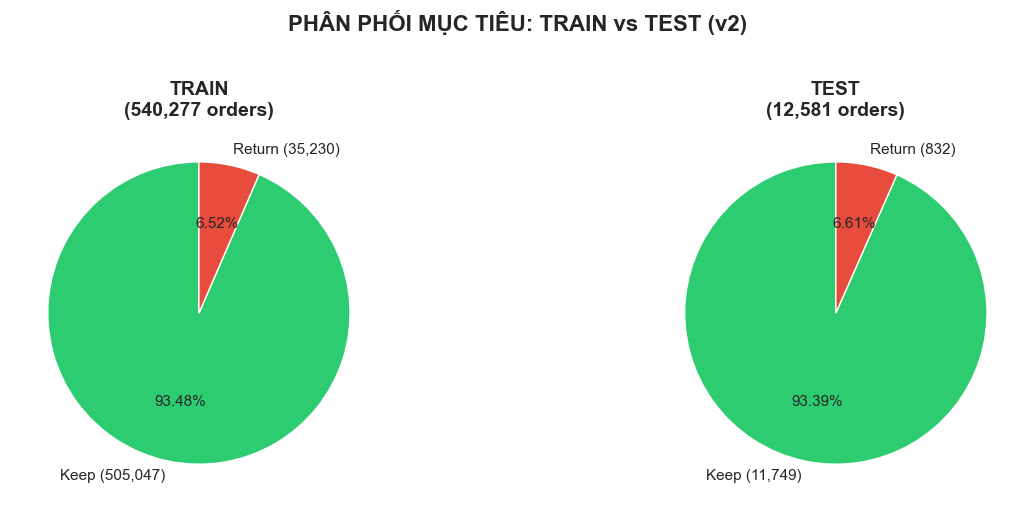

In [50]:
# Visualize split
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title in [(axes[0], df_train, 'TRAIN'), (axes[1], df_test, 'TEST')]:
    sizes = [df['is_returned'].value_counts()[0], df['is_returned'].value_counts()[1]]
    labels = [f'Keep ({sizes[0]:,})', f'Return ({sizes[1]:,})']
    ax.pie(sizes, labels=labels, colors=['#2ecc71', '#e74c3c'],
           autopct='%1.2f%%', startangle=90, textprops={'fontsize': 11})
    ax.set_title(f'{title}\n({df.shape[0]:,} orders)', fontsize=14, fontweight='bold')

plt.suptitle('PHÂN PHỐI MỤC TIÊU: TRAIN vs TEST (v2)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 11. Lưu Dataset

In [51]:
import json

save_cols = ID_COLS + NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET_COL]
save_cols = [c for c in save_cols if c in df_base.columns]

df_base[save_cols].to_csv(os.path.join(DATA_DIR, 'return_prediction_features_v2.csv'), index=False)
print(f'Đã lưu return_prediction_features_v2.csv ({df_base.shape[0]:,} rows × {len(save_cols)} cols)')

feature_config = {
    'version': 'v2',
    'id_columns': ID_COLS,
    'target_column': TARGET_COL,
    'numeric_features': NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'cutoff_date': CUTOFF_DATE,
    'total_features': len(NUMERIC_FEATURES) + len(CATEGORICAL_FEATURES),
    'granularity': 'order_id',
    'changes_from_v1': [
        'Removed max_unit_price (multicollinear with avg_unit_price, r=0.998)',
        'Removed min_unit_price (replaced by price_range)',
        'Removed device_type (noise feature, EDA: flat return rate ~6.5%)',
        'Fixed data leakage: category/region/payment return rates now use expanding mean',
        'Fixed data leakage: customer review features now use cumulative leakage-safe',
        'Added is_cod binary feature (COD return rate 11.33% vs prepaid ~5.7%)',
        'Added items_per_product (bulk buying behavior)',
        'Added discount_ratio (actual discount percentage)',
        'Added size_variety_ratio (proxy for size trial behavior)',
        'Added color_variety_ratio (color diversity in order)',
        'Added avg_value_per_item (average value per item)',
        'Added customer_return_tendency (return rate × order experience)',
    ]
}
with open(os.path.join(DATA_DIR, 'return_prediction_feature_config_v2.json'), 'w') as f:
    json.dump(feature_config, f, indent=2)

print(f'\nĐã lưu return_prediction_feature_config_v2.json')
print(f'  Total: {feature_config["total_features"]} features')
print(f'  Version: {feature_config["version"]}')

Đã lưu return_prediction_features_v2.csv (552,858 rows × 66 cols)

Đã lưu return_prediction_feature_config_v2.json
  Total: 62 features
  Version: v2


## 12. [v2] Verification: Kiểm tra Leakage-safe

Verify rằng các target-encoded features đã thực sự leakage-safe.

In [52]:
# Verify leakage-safe: đơn hàng ĐẦU TIÊN của mỗi category/region/payment
# phải có return rate = 0 (vì chưa có lịch sử)

df_check = df_base.sort_values('order_date')

# Category: đơn đầu tiên của mỗi category
first_per_cat = df_check.groupby('dominant_category').first()
print('=== VERIFY LEAKAGE-SAFE ===')
print(f'category_hist_return_rate tại đơn đầu tiên mỗi category: '
      f'{first_per_cat["category_hist_return_rate"].unique()}')

# Region
first_per_reg = df_check.groupby('region').first()
print(f'region_hist_return_rate tại đơn đầu tiên mỗi region: '
      f'{first_per_reg["region_hist_return_rate"].unique()}')

# Payment
first_per_pay = df_check.groupby('payment_method').first()
print(f'payment_hist_return_rate tại đơn đầu tiên mỗi payment: '
      f'{first_per_pay["payment_hist_return_rate"].unique()}')

# Customer: đơn đầu tiên phải có return_rate = 0
first_orders = df_check[df_check['is_first_order'] == 1]
print(f'\ncustomer_return_rate tại đơn đầu tiên: '
      f'unique values = {first_orders["customer_return_rate"].unique()}')

print('\n✅ Nếu tất cả = [0.0] → Leakage-safe đã hoạt động đúng!')

=== VERIFY LEAKAGE-SAFE ===
category_hist_return_rate tại đơn đầu tiên mỗi category: [0.     0.0625]
region_hist_return_rate tại đơn đầu tiên mỗi region: [0.]
payment_hist_return_rate tại đơn đầu tiên mỗi payment: [0.]

customer_return_rate tại đơn đầu tiên: unique values = [0.]

✅ Nếu tất cả = [0.0] → Leakage-safe đã hoạt động đúng!


## 13. Kết luận

### Thay đổi so với v1:
- **Loại bỏ 3 features:** `max_unit_price`, `min_unit_price`, `device_type`
- **Thêm 7 features mới:** `is_cod`, `items_per_product`, `discount_ratio`, `size_variety_ratio`, `color_variety_ratio`, `avg_value_per_item`, `customer_return_tendency`
- **Sửa 6 features leakage:** 3 target-encoded + 3 customer review features

### Bước tiếp theo:
- Sử dụng `return_prediction_features_v2.csv` trong notebook modeling
- Huấn luyện LightGBM/XGBoost với Temporal Split
- Đánh giá bằng PR-AUC, F1-Score và Threshold Optimization (do class imbalance 93.5% : 6.5%)